# S4oP (s4, s4d, mamba, mamba2)

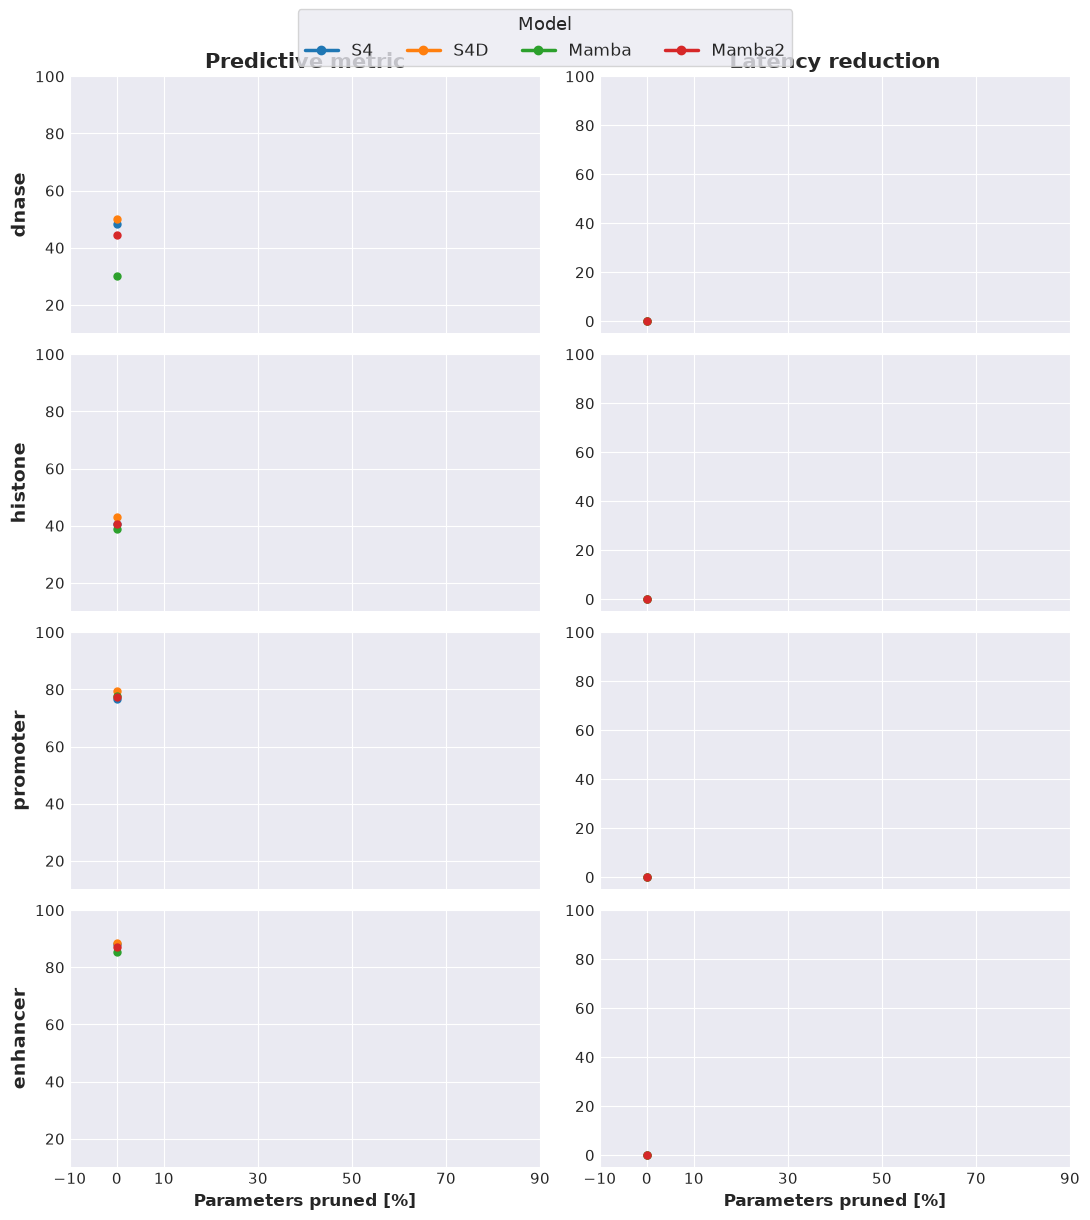


=== ACCURACY — media [min-max] su s4/s4d/mamba/mamba2 ===
dataset     model                   0%             10%             30%             50%             70%             90%
----------------------------------------------------------------------------------------------------------------------
dnase       s4                    48.4              --              --              --              --              --   (n=1)
dnase       s4d                   50.1              --              --              --              --              --   (n=1)
dnase       mamba                 30.1              --              --              --              --              --   (n=1)
dnase       mamba2                44.3              --              --              --              --              --   (n=1)
histone     s4                    40.7              --              --              --              --              --   (n=1)
histone     s4d                   42.9              --              

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pruning_rates = [0, 10, 30, 50, 70, 90]

datasets = ["dnase", "histone", "promoter", "enhancer"]
models   = ["s4", "s4d", "mamba", "mamba2"]

N = len(pruning_rates)

results = {
    "accuracy": {
        "s4": {
            "dnase":    [[48.388, None, None, None, None, None]],
            "histone":  [[40.688, None, None, None, None, None]],
            "promoter": [[76.748, None, None, None, None, None]],
            "enhancer": [[88.158, None, None, None, None, None]],
        },
        "s4d": {
            "dnase":    [[50.063, None, None, None, None, None]],
            "histone":  [[42.945, None, None, None, None, None]],
            "promoter": [[79.361, None, None, None, None, None]],
            "enhancer": [[88.422, None, None, None, None, None]],
        },
        "mamba": {
            "dnase":    [[30.070, None, None, None, None, None]],
            "histone":  [[38.909, None, None, None, None, None]],
            "promoter": [[77.521, None, None, None, None, None]],
            "enhancer": [[85.249, None, None, None, None, None]],
        },
        "mamba2": {
            "dnase":    [[44.328, None, None, None, None, None]],
            "histone":  [[40.587, None, None, None, None, None]],
            "promoter": [[77.226, None, None, None, None, None]],
            "enhancer": [[87.119, None, None, None, None, None]],
        },
    },
    "speedup": {
        "s4": {
            "dnase":    [[0, None, None, None, None, None]],
            "histone":  [[0, None, None, None, None, None]],
            "promoter": [[0, None, None, None, None, None]],
            "enhancer": [[0, None, None, None, None, None]],
        },
        "s4d": {
            "dnase":    [[0, None, None, None, None, None]],
            "histone":  [[0, None, None, None, None, None]],
            "promoter": [[0, None, None, None, None, None]],
            "enhancer": [[0, None, None, None, None, None]],
        },
        "mamba": {
            "dnase":    [[0, None, None, None, None, None]],
            "histone":  [[0, None, None, None, None, None]],
            "promoter": [[0, None, None, None, None, None]],
            "enhancer": [[0, None, None, None, None, None]],
        },
        "mamba2": {
            "dnase":    [[0, None, None, None, None, None]],
            "histone":  [[0, None, None, None, None, None]],
            "promoter": [[0, None, None, None, None, None]],
            "enhancer": [[0, None, None, None, None, None]],
        },
    },
}

model_colors = {"s4": "tab:blue", "s4d": "tab:orange", "mamba": "tab:green", "mamba2": "tab:red"}
model_labels = {"s4": "S4", "s4d": "S4D", "mamba": "Mamba", "mamba2": "Mamba2"}

dataset_labels = {"dnase": "dnase", "histone": "histone", "promoter": "promoter", "enhancer": "enhancer"}

metrics = ["accuracy", "speedup"]
metric_titles  = {"accuracy": "Predictive metric", "speedup": "Latency reduction"}
metric_ylabels = {"accuracy": "AUPRC", "speedup": "Latency reduction [%]"}
metric_ylims   = {"accuracy": (10, 100), "speedup": (-5, 100)}


def to_array(list_of_runs):
    """Converte [[seed1],[seed2],...] in un array (n_seed, N); None e valori mancanti -> NaN."""
    arr = np.full((len(list_of_runs), N), np.nan)
    for k, run in enumerate(list_of_runs):
        for p, v in enumerate(run[:N]):
            if v is not None:
                arr[k, p] = v
    return arr


def mean_band(list_of_runs):
    """(media, min, max) per pruning rate sui seed, ignorando i NaN."""
    arr = to_array(list_of_runs)
    if arr.shape[0] == 0:
        return (np.full(N, np.nan),) * 3
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean = np.nanmean(arr, axis=0)
        lo   = np.nanmin(arr, axis=0)
        hi   = np.nanmax(arr, axis=0)
    return mean, lo, hi


def n_valid_seeds(list_of_runs):
    arr = to_array(list_of_runs)
    return int((~np.isnan(arr)).any(axis=1).sum())


plt.style.use("seaborn-v0_8-darkgrid")
nrows, ncols = len(datasets), len(metrics)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(11, 3.0 * nrows),
                         squeeze=False, sharex=True)

x = np.array(pruning_rates)

for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i][j]
        for model in models:
            runs = results[metric][model][dataset]
            mean, lo, hi = mean_band(runs)
            valid = ~np.isnan(mean)
            if not valid.any():
                continue
            c = model_colors[model]
            ax.fill_between(x[valid], lo[valid], hi[valid],
                            color=c, alpha=0.18, linewidth=0)
            ax.plot(x[valid], mean[valid], marker="o", markersize=5,
                    linewidth=2, color=c, label=model_labels[model])

        if j == 0:
            ax.set_ylabel(dataset_labels[dataset], fontsize=14, fontweight="bold")
        if i == 0:
            ax.set_title(metric_titles[metric], fontsize=15, fontweight="bold")
        if i == nrows - 1:
            ax.set_xlabel("Parameters pruned [%]", fontsize=12, fontweight="bold")

        ax.set_ylim(*metric_ylims[metric])
        ax.set_xticks([-10] + pruning_rates)
        ax.tick_params(axis="both", which="major", labelsize=11)
        ax.grid(True)

handles = [Line2D([0], [0], color=model_colors[m], lw=2.5, marker="o",
                  label=model_labels[m]) for m in models]
fig.legend(handles=handles, title="Model", loc="upper center",
           ncol=len(models), bbox_to_anchor=(0.5, 1.02),
           fontsize=12, title_fontsize=13, frameon=True)

fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig("pruning_comparison_grid.png", dpi=200, bbox_inches="tight")
plt.show()


def print_table(metric, show_range=True):
    COLW = 16 if show_range else 8
    print(f"\n=== {metric.upper()} — media [min-max] su {'/'.join(models)} ===")
    header = f"{'dataset':<12}{'model':<10}" + "".join(
        f"{str(r) + '%':>{COLW}}" for r in pruning_rates)
    print(header)
    print("-" * len(header))
    for dataset in datasets:
        for model in models:
            runs = results[metric][model][dataset]
            mean, lo, hi = mean_band(runs)
            ns = n_valid_seeds(runs)
            cells = ""
            for m, l, h in zip(mean, lo, hi):
                if np.isnan(m):
                    cells += f"{'--':>{COLW}}"
                elif show_range and ns > 1 and (h - l) > 0.05:
                    cells += f"{f'{m:.1f}[{l:.1f},{h:.1f}]':>{COLW}}"
                else:
                    cells += f"{m:>{COLW}.1f}"
            print(f"{dataset:<12}{model:<10}{cells}   (n={ns})")


for metric in metrics:
    print_table(metric)